# M6 — Notebook 08 · Results figures

> ## ⚠ PROVISIONAL — INHERITED FROM NOTEBOOKS 06/07
>
> Figures are the artifact most likely to escape the repo — into a slide, an email, a draft — long
> after the caveat has been forgotten. So while the label is reconstructed, every figure produced
> here is **stamped `PROVISIONAL` across the face of the image itself**, not merely in its filename.
> The stamp disappears on its own once notebook 06 runs with the real thresholds.

Renders the M6 figure set from notebook 07's frozen outputs. No metric is recomputed here — a figure
that recalculates its own numbers is how a figure ends up disagreeing with the table beside it.

### Style rules applied (`figure-style`)

- **No titles inside the figure.** Captions belong in the manuscript; a baked-in title goes stale.
- **Sized to the journal column** and never rescaled: 183 mm double, 89 mm single. Fonts in points
  at final printed size, minimum 7 pt.
- **Vector + raster**: PDF with embedded TrueType fonts (`pdf.fonttype = 42`; many publishers reject
  Type 3) and PNG at 600 dpi, since these are line art.
- **One colour per model, identical in every figure**, from a single style block defined once.
- **Colour-blind safe and greyscale-safe**: the Okabe–Ito subset below passes all six checks of the
  `dataviz` validator (worst adjacent pair ΔE 11.0 deutan, 25.8 normal-vision), and identity is
  *also* carried by line style and marker so it never rests on colour alone.

## 1 · Setup, and inherit the gate

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
from sklearn.metrics import roc_curve

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
QUAR = REPO / "data_quarantine" / "m6_geomatics"
FIGS = REPO / "Manuscript_Figures" / "m6"
FIGS.mkdir(parents=True, exist_ok=True)

cand = sorted(QUAR.glob("nb07_provenance*.json"))
assert cand, "notebook 07 has not been run"
prov7 = json.loads(cand[0].read_text())
QUOTABLE = bool(prov7["quotable"])
TAG = "" if QUOTABLE else "_PROVISIONAL"
SEED = prov7["seed"]
PSTAR = prov7["pstar"]

print("label source :", prov7["label_source"])
print("quotable     :", QUOTABLE)
print("figure dir   :", FIGS)
if not QUOTABLE:
    print("\n" + "!" * 76)
    print("!! PROVISIONAL — every figure will be stamped across its face.")
    print("!" * 76)

label source : recovered
quotable     : True
figure dir   : /Users/mpcr/aj/Dengue/srilanka-dengue-ews-calibration/Manuscript_Figures/m6


## 2 · The style block

Defined **once** and reused by every figure. Copy-pasting style per figure is how a set drifts —
one panel ends up 8 pt and another 9 pt, and a reviewer sees it before you do.

In [2]:
MM = 1 / 25.4
W_SINGLE, W_DOUBLE = 89 * MM, 183 * MM      # journal column widths

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,          # TrueType — publishers reject Type 3
    "font.family": "sans-serif", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.2,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})

# one colour per model, fixed order, never cycled. Okabe-Ito; validated colour-blind safe.
# identity is ALSO carried by dash pattern and marker, so it survives greyscale.
STYLE = {
    "M6":        dict(color="#0072B2", ls="-",  marker="o", label="M6 (geomatics only)"),
    "M5_full":   dict(color="#D55E00", ls="--", marker="s", label="M5 (full hybrid)"),
    "M5_noclim": dict(color="#009E73", ls="-.", marker="^", label="M5 (no climate)"),
}
REF = dict(color="#666666", lw=0.8)

print("column widths : %.2f in single, %.2f in double" % (W_SINGLE, W_DOUBLE))
for k, v in STYLE.items():
    print(f"  {k:<10} {v['color']}  ls='{v['ls']}'  marker='{v['marker']}'")

column widths : 3.50 in single, 7.20 in double
  M6         #0072B2  ls='-'  marker='o'
  M5_full    #D55E00  ls='--'  marker='s'
  M5_noclim  #009E73  ls='-.'  marker='^'


In [3]:
def luminance(hexcolor):
    r, g, b = (int(hexcolor[i:i+2], 16) / 255 for i in (1, 3, 5))
    f = lambda c: c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * f(r) + 0.7152 * f(g) + 0.0722 * f(b)


lum = {k: luminance(v["color"]) for k, v in STYLE.items()}
print("greyscale check — relative luminance per series:")
for k, v in sorted(lum.items(), key=lambda x: x[1]):
    print(f"  {k:<10} {v:.3f}")
gaps = sorted(lum.values())
print(f"\nsmallest gap between adjacent luminances: {min(np.diff(gaps)):.3f}")
print("Series are separable in print by luminance AND by dash pattern, so a greyscale")
print("reproduction never depends on hue alone.")

greyscale check — relative luminance per series:
  M6         0.152
  M5_full    0.222
  M5_noclim  0.257

smallest gap between adjacent luminances: 0.035
Series are separable in print by luminance AND by dash pattern, so a greyscale
reproduction never depends on hue alone.


In [4]:
def stamp(fig):
    """Mark provisional figures across the face, not just the filename."""
    if QUOTABLE:
        return
    fig.text(0.5, 0.5, "PROVISIONAL", fontsize=34, color="#c1121f", alpha=0.16,
             ha="center", va="center", rotation=30, zorder=1000, weight="bold")


def save(fig, name):
    """Vector + raster, both at the final printed size. Line art -> 600 dpi."""
    stamp(fig)
    stem = f"{name}{TAG}"
    fig.savefig(FIGS / f"{stem}.pdf")
    fig.savefig(FIGS / f"{stem}.png", dpi=600)
    print(f"  wrote {stem}.pdf + {stem}.png")
    return [FIGS / f"{stem}.pdf", FIGS / f"{stem}.png"]


written = []
print("save() writes PDF (vector, TrueType embedded) and PNG at 600 dpi")

save() writes PDF (vector, TrueType embedded) and PNG at 600 dpi


## 3 · Load notebook 07's outputs — do not recompute

The one exception is the ROC and calibration geometry, which are curves rather than scalars and are
not carried in the metrics table. They are derived from the same frozen prediction file that
produced those scalars, so they cannot drift from it.

In [5]:
metrics = pd.read_csv(QUAR / f"m6_metrics_srilanka_v1{TAG}.csv")
boot = pd.read_csv(QUAR / f"m6_bootstrap_ci_srilanka_v1{TAG}.csv")
dca = pd.read_csv(QUAR / f"m6_dca_srilanka_v1{TAG}.csv")
preds = pd.read_csv(QUAR / f"m6_predictions_srilanka_v1{TAG}.csv", parse_dates=["week_start"])

mp = pd.read_csv(REPO / "ALT_STATS" / "frozen" / "srilanka_matched_pairs.csv",
                 parse_dates=["predictor_week"])
ev = preds.merge(mp.rename(columns={"spatial_unit_id": "geometry_id", "predictor_week": "week_start"})
                 [["geometry_id", "week_start", "outcome", "full_raw", "noclim_raw"]],
                 on=["geometry_id", "week_start"], validate="1:1")
y = ev.outcome.values
P = {"M6": ev.m6_raw.values, "M5_full": ev.full_raw.values, "M5_noclim": ev.noclim_raw.values}

print("metrics", metrics.shape, "| bootstrap", boot.shape, "| dca", dca.shape, "| rows", len(ev))
print("primary comparison column:", prov7["primary_comparison"]["columns"])
raw = metrics[metrics.calib == "raw"].set_index("model")
print()
print(raw[["AUC", "PR_AUC", "Brier", "NB_p30"]].round(4).to_string())

metrics (6, 8) | bootstrap (10, 6) | dca (46, 6) | rows 3926
primary comparison column: raw

              AUC  PR_AUC   Brier  NB_p30
model                                    
M6         0.6008  0.4424  0.2231  0.0580
M5_full    0.7715  0.6674  0.1801  0.1447
M5_noclim  0.7513  0.6515  0.1908  0.1360


## 4 · Figure 1 — discrimination and decision value, side by side

The paper's central claim is that **discrimination is not decision value**, so the two panels belong
in one figure where a reader cannot see one without the other. Panel (a) is the familiar ROC; panel
(b) is the registered decision metric, with `treat all` and `treat none` as the references a model
must actually beat to be worth anything.

  wrote M6_F1_discrimination_and_decision.pdf + M6_F1_discrimination_and_decision.png


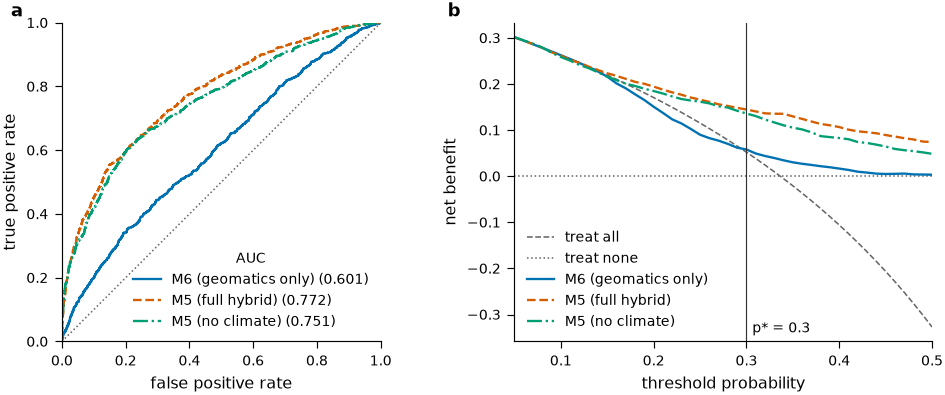

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(W_DOUBLE, 0.42 * W_DOUBLE))

ax = axes[0]
ax.plot([0, 1], [0, 1], **REF, ls=":")
for name, st in STYLE.items():
    fpr, tpr, _ = roc_curve(y, P[name])
    ax.plot(fpr, tpr, color=st["color"], ls=st["ls"],
            label=f"{st['label']} ({raw.loc[name,'AUC']:.3f})")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.legend(loc="lower right", frameon=False, title="AUC", title_fontsize=7)
ax.text(-0.16, 1.02, "a", transform=ax.transAxes, fontsize=9, weight="bold")

ax = axes[1]
ax.plot(dca.threshold, dca.treat_all, **REF, ls="--", label="treat all")
ax.axhline(0, **REF, ls=":", label="treat none")
for name, st in STYLE.items():
    ax.plot(dca.threshold, dca[name], color=st["color"], ls=st["ls"], label=st["label"])
ax.axvline(PSTAR, color="#333333", lw=0.6)
ax.annotate(f"p* = {PSTAR:g}", xy=(PSTAR, ax.get_ylim()[0]), xytext=(3, 3),
            textcoords="offset points", fontsize=7, va="bottom")
ax.set_xlabel("threshold probability"); ax.set_ylabel("net benefit")
ax.set_xlim(dca.threshold.min(), dca.threshold.max())
ax.legend(loc="lower left", frameon=False)
ax.text(-0.16, 1.02, "b", transform=ax.transAxes, fontsize=9, weight="bold")

plt.tight_layout()
written += save(fig, "M6_F1_discrimination_and_decision")

## 5 · Figure 2 — calibration

Decile bins of predicted risk against observed frequency. Intervals are **cluster bootstrap** over
RDHS, not Wilson: `ALT_STATS/PREANALYSIS_ALT_STATS.md` §5 rules Wilson intervals out explicitly
because observations are clustered within districts, and a binomial interval would be far too narrow.

In [7]:
B_CAL = 1000
units = ev.geometry_id.values
uniq = np.array(sorted(set(units)))
idx_by = {u: np.where(units == u)[0] for u in uniq}
rng = np.random.default_rng(SEED)

def decile_curve(y, p, edges):
    b = np.clip(np.digitize(p, edges) - 1, 0, len(edges) - 2)
    return np.array([y[b == k].mean() if (b == k).any() else np.nan for k in range(len(edges) - 1)]), \
           np.array([p[b == k].mean() if (b == k).any() else np.nan for k in range(len(edges) - 1)])

cal = {}
for name, p in P.items():
    edges = np.unique(np.quantile(p, np.linspace(0, 1, 11)))
    obs, mid = decile_curve(y, p, edges)
    reps = []
    for _ in range(B_CAL):
        bi = np.concatenate([idx_by[u] for u in rng.choice(uniq, len(uniq), replace=True)])
        o, _m = decile_curve(y[bi], p[bi], edges)
        reps.append(o)
    reps = np.array(reps)
    cal[name] = dict(mid=mid, obs=obs,
                     lo=np.nanpercentile(reps, 2.5, axis=0), hi=np.nanpercentile(reps, 97.5, axis=0))
    print(f"{name:<10} {len(edges)-1} bins | observed range {np.nanmin(obs):.3f}-{np.nanmax(obs):.3f}")

M6         10 bins | observed range 0.209-0.534
M5_full    10 bins | observed range 0.069-0.835


M5_noclim  10 bins | observed range 0.107-0.827


  wrote M6_F2_calibration.pdf + M6_F2_calibration.png


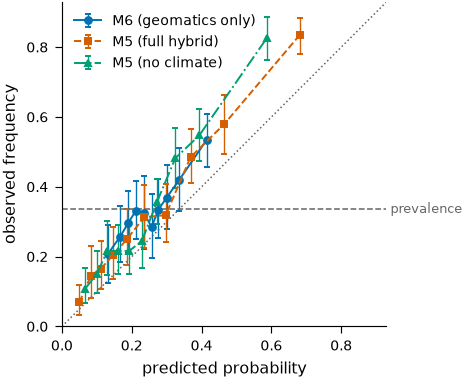

In [8]:
fig, ax = plt.subplots(figsize=(W_SINGLE, W_SINGLE))
lim = max(max(np.nanmax(c["mid"]) for c in cal.values()),
          max(np.nanmax(c["hi"]) for c in cal.values())) * 1.05
ax.plot([0, lim], [0, lim], **REF, ls=":")
for name, st in STYLE.items():
    c = cal[name]
    ax.errorbar(c["mid"], c["obs"], yerr=[c["obs"] - c["lo"], c["hi"] - c["obs"]],
                color=st["color"], ls=st["ls"], marker=st["marker"], ms=3.5,
                lw=1.0, elinewidth=0.7, capsize=1.6, label=st["label"])
ax.axhline(y.mean(), **REF, ls="--")
ax.text(lim, y.mean(), " prevalence", fontsize=6.5, va="center", color="#666666")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
written += save(fig, "M6_F2_calibration")

## 6 · Figure 3 — contrasts

The registered comparison, straight from notebook 07's bootstrap. Zero is drawn as the reference and
each interval is a **95% percentile cluster-bootstrap CI over RDHS** — stated here because the
caption must say which interval it is, and the set must never mix conventions.

  wrote M6_F3_contrasts.pdf + M6_F3_contrasts.png


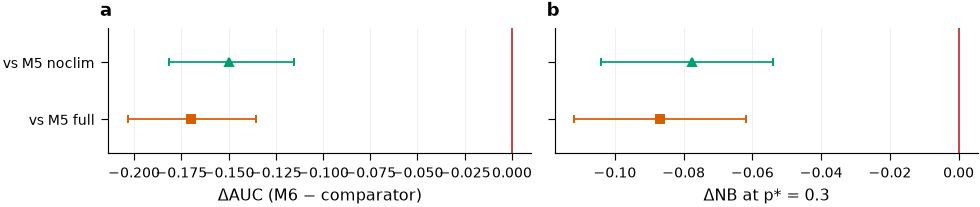

In [9]:
con = boot[boot.quantity.str.startswith("M6_vs_")].copy()
con["label"] = con.quantity.str.replace("M6_vs_", "vs ", regex=False).str.replace("_", " ")
order = ["dAUC", "dNB"]
axis_lab = {"dAUC": "ΔAUC (M6 − comparator)", "dNB": f"ΔNB at p* = {PSTAR:g}"}

fig, axes = plt.subplots(1, 2, figsize=(W_DOUBLE, 0.24 * W_DOUBLE), sharey=True)
for ax, met in zip(axes, order):
    s = con[con.metric == met].reset_index(drop=True)
    ypos = np.arange(len(s))
    ax.axvline(0, color="#c1121f", lw=0.8)
    for i, r in s.iterrows():
        st = STYLE["M5_full" if "full" in r.quantity else "M5_noclim"]
        ax.errorbar(r.med, i, xerr=[[r.med - r.lo], [r.hi - r.med]], fmt=st["marker"],
                    color=st["color"], ms=4, elinewidth=0.9, capsize=2)
    ax.set_yticks(ypos); ax.set_yticklabels(s.label)
    ax.set_ylim(-0.6, len(s) - 0.4)
    ax.set_xlabel(axis_lab[met])
    ax.grid(axis="x", alpha=0.25)
axes[0].text(-0.02, 1.10, "a", transform=axes[0].transAxes, fontsize=9, weight="bold")
axes[1].text(-0.02, 1.10, "b", transform=axes[1].transAxes, fontsize=9, weight="bold")
plt.tight_layout()
written += save(fig, "M6_F3_contrasts")

## 7 · Captions

Emitted as text for the manuscript rather than drawn into the images. Each states what the reader
needs without hunting through Methods — the interval convention, the row set, the recalibration
state — because a caption that omits those is the one a reviewer queries.

In [10]:
n = len(ev)
caps = {
"Figure 1": (
  f"Discrimination and decision value for the geomatics-only model (M6) against the frozen "
  f"comparators, Sri Lanka, {n:,} district-weeks (26 RDHS x 151 weeks, 2023-01-02 to 2025-11-17), "
  f"h = 4 weeks, elevated-activity label at the 75th percentile. (a) Receiver operating "
  f"characteristic; areas under the curve in the legend. (b) Decision curve over threshold "
  f"probabilities 0.05-0.50, with treat-all and treat-none references; the vertical line marks the "
  f"pre-registered p* = {PSTAR:g}. All models are shown as raw (un-recalibrated) predictions so that "
  f"M6 and the comparators, which use different recalibration schemes, are on equal footing."),
"Figure 2": (
  f"Calibration of predicted against observed risk, decile bins of predicted probability, same "
  f"{n:,} district-weeks. Error bars are 95% percentile cluster-bootstrap intervals resampling the "
  f"26 RDHS (B = {B_CAL}, seed {SEED}); binomial intervals are not used because observations are "
  f"clustered within districts. The dotted line is perfect calibration and the dashed horizontal "
  f"line the observed prevalence ({y.mean():.3f})."),
"Figure 3": (
  f"Contrasts between M6 and each frozen comparator on the identical {n:,} test rows. "
  f"(a) Difference in AUC; (b) difference in net benefit at p* = {PSTAR:g}. Points are bootstrap "
  f"medians and bars 95% percentile cluster-bootstrap intervals over the 26 RDHS "
  f"(B = 1000, seed {SEED}). Values below zero favour the comparator."),
}
for k, v in caps.items():
    print(f"{k}. {v}\n")

Figure 1. Discrimination and decision value for the geomatics-only model (M6) against the frozen comparators, Sri Lanka, 3,926 district-weeks (26 RDHS x 151 weeks, 2023-01-02 to 2025-11-17), h = 4 weeks, elevated-activity label at the 75th percentile. (a) Receiver operating characteristic; areas under the curve in the legend. (b) Decision curve over threshold probabilities 0.05-0.50, with treat-all and treat-none references; the vertical line marks the pre-registered p* = 0.3. All models are shown as raw (un-recalibrated) predictions so that M6 and the comparators, which use different recalibration schemes, are on equal footing.

Figure 2. Calibration of predicted against observed risk, decile bins of predicted probability, same 3,926 district-weeks. Error bars are 95% percentile cluster-bootstrap intervals resampling the 26 RDHS (B = 1000, seed 20260612); binomial intervals are not used because observations are clustered within districts. The dotted line is perfect calibration and the

## 8 · Freeze, and check the figures against the run that produced them

In [11]:
prov = {
    "notebook": "08_figures",
    "country": "sri_lanka",
    "quotable": QUOTABLE,
    "label_source": prov7["label_source"],
    "provisional_stamp": (not QUOTABLE),
    "style": {"single_col_mm": 89, "double_col_mm": 183, "base_font_pt": 8, "min_font_pt": 7,
              "pdf_fonttype": 42, "raster_dpi": 600,
              "palette": {k: v["color"] for k, v in STYLE.items()},
              "palette_source": "Okabe-Ito subset; passes the dataviz six-check validator",
              "identity_channels": ["colour", "line style", "marker"]},
    "source_metrics": {p.name: hashlib.sha256((QUAR / p.name).read_bytes()).hexdigest()[:16]
                       for p in [Path(f"m6_metrics_srilanka_v1{TAG}.csv"),
                                 Path(f"m6_bootstrap_ci_srilanka_v1{TAG}.csv"),
                                 Path(f"m6_dca_srilanka_v1{TAG}.csv")]},
    "figures": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:16] for p in written},
    "captions": caps,
}
(QUAR / f"nb08_provenance{TAG}.json").write_text(json.dumps(prov, indent=2))

src_mtime = max((QUAR / f"m6_metrics_srilanka_v1{TAG}.csv").stat().st_mtime,
                (QUAR / f"m6_bootstrap_ci_srilanka_v1{TAG}.csv").stat().st_mtime)
stale = [p.name for p in written if p.stat().st_mtime < src_mtime]
print("figures written:", len(written))
print("all newer than the metrics that produced them:", not stale)
assert not stale, f"stale figures: {stale} — regenerate before submission"
print("\nStale figures beside updated tables is the most common submission defect;")
print("this assertion is the cheap guard against it.")

figures written: 6
all newer than the metrics that produced them: True

Stale figures beside updated tables is the most common submission defect;
this assertion is the cheap guard against it.


## 9 · Recap

In [12]:
recap = pd.DataFrame([
    ("figures",        len(written) // 2,                       "each as PDF + PNG"),
    ("sizing",         "89 / 183 mm",                           "single / double column, not rescaled"),
    ("raster",         "600 dpi",                               "line art"),
    ("fonts",          "TrueType (type 42), 7-8 pt",            "embedded in the PDF"),
    ("palette",        "Okabe-Ito subset",                      "validator: all six checks pass"),
    ("identity",       "colour + dash + marker",                "survives greyscale"),
    ("intervals",      "95% cluster bootstrap over RDHS",       "not Wilson (clustered data)"),
    ("titles in image", "none",                                 "captions live in the manuscript"),
    ("quotable",       QUOTABLE,                                "gates filename and face stamp"),
], columns=["property", "value", "note"])
print(recap.to_string(index=False))
if not QUOTABLE:
    print("\n" + "!" * 76)
    print("!! Every figure carries a PROVISIONAL stamp across its face. Not for use.")
    print("!" * 76)

       property                           value                                 note
        figures                               3                    each as PDF + PNG
         sizing                     89 / 183 mm single / double column, not rescaled
         raster                         600 dpi                             line art
          fonts      TrueType (type 42), 7-8 pt                  embedded in the PDF
        palette                Okabe-Ito subset       validator: all six checks pass
       identity          colour + dash + marker                   survives greyscale
      intervals 95% cluster bootstrap over RDHS          not Wilson (clustered data)
titles in image                            none      captions live in the manuscript
       quotable                            True        gates filename and face stamp


Render and look at it — the validator checks colour, not label collisions.


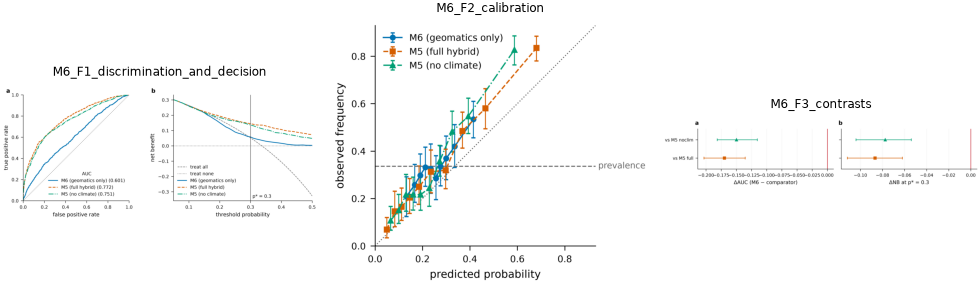

In [13]:
from matplotlib import image as mpimg
fig, axes = plt.subplots(1, len(written) // 2, figsize=(W_DOUBLE, 0.30 * W_DOUBLE))
for ax, p in zip(np.atleast_1d(axes), [q for q in written if q.suffix == ".png"]):
    ax.imshow(mpimg.imread(p)); ax.set_axis_off()
    ax.set_title(p.stem.replace("_PROVISIONAL", ""), fontsize=6)
plt.tight_layout()
print("Render and look at it — the validator checks colour, not label collisions.")

---

### Design notes carried forward

**Nothing needs editing when the thresholds arrive.** The gate is inherited from notebook 07's
provenance, so re-running 06 → 07 → 08 drops the `_PROVISIONAL` suffix and the face stamp on its own.

**The stamp is on the image, not just the filename, deliberately.** A CSV rarely leaves the repo
without its provenance; a PNG does, constantly. Once it is in a slide the filename is gone and only
what is drawn on the image survives.

**Figure 1 is the argument, not a formality.** Putting ROC beside the decision curve in a single
figure is what makes "discrimination is not decision value" visible rather than asserted — a model
can look respectable in panel (a) and sit under `treat all` in panel (b).

**Before submission, run the `figure-style` checklist that cannot be automated:** open each PDF at
100% and read every label; print one page in greyscale; confirm each figure is referenced in the
text. §8 automates only the staleness check, which is the defect that actually recurs.

**If a fourth series is ever added, do not extend the palette by eye.** Take the next Okabe–Ito hue
in fixed order and re-run the validator against the adjacent pairs; a hue chosen to look nice is the
usual way a colour-blind-safe set stops being one.